In [ ]:
# Gõ dòng này vào cell đầu tiên và bấm Run (Shift + Enter) or Run All
get_ipython().run_line_magic('run', '../_setup.py')

In [ ]:
from functools import partial, reduce

import statsmodels.api as sm
from matplotlib.ticker import MaxNLocator
from prophet import Prophet
from statsforecast import StatsForecast
from statsforecast.adapters.prophet import AutoARIMAProphet
from statsforecast.models import MSTL, AutoETS, AutoARIMA, ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.api import VAR
from utilsforecast.evaluation import evaluate
from utilsforecast.feature_engineering import trend, fourier, pipeline
from utilsforecast.losses import rmse, mae, mape, mase
from utilsforecast.preprocessing import fill_gaps

In [ ]:
BASE_DIR = Path.cwd().parent.parent
DATA_DIR = BASE_DIR / "data"
print(DATA_DIR)

### 1. Compare STL and Dynamic Harmonic Regression forecasts for one of the series in the `pedestrian` data set.

a. Try modifying the order of the Fourier terms to minimise the AICc value.

b. Check the residuals for each model. Do they capture the available information in the data?

c. Which of the two sets of forecasts are best? Explain.

In [ ]:
data = (
    pd.read_csv(DATA_DIR / "pedestrian.csv", parse_dates=["Date_Time"])
    [["unique_id", "Date_Time", "y"]]
    .rename(columns={"unique_id": "unique_id", "Date_Time": "ds", "y": "y"})
    .query("unique_id=='QV Market-Elizabeth St (West)'")
    .reset_index(drop=True)
)
data['ds'] = pd.to_datetime(data['ds'], format='mixed')
data = data.sort_values('ds').reset_index(drop=True)

plot_series(data, time_col = "ds", target_col = "y", title="Hourly Pedestrian Counts")

In [ ]:
models = [MSTL(season_length=[24, 168, 8766])]
sf = StatsForecast(models=models, freq='H', n_jobs=-1)
sf.fit(data, target_col='y')
dcmp = sf.fitted_[0, 0].model_

fig, axes = plt.subplots(6, figsize=(8, 7), sharex=True)
for (ax, column) in zip(axes, dcmp.columns):
    sns.lineplot(data=dcmp, x=dcmp.index, y=column, ax=ax, color="k")
# axes[0].set_title(
#     "sqrt(Calls) = trend + seasonal169 + seasonal845 + remainder",
#     size="medium", loc="left")
axes[-1].set(xlabel="")
fig.suptitle("STL decomposition")
plt.show()

In [ ]:
mstl_res = dcmp["remainder"]
fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(data["ds"], mstl_res, marker=".")
axes["resid"].set(xlabel="Time", ylabel="Innovation Residuals")
plot_acf(mstl_res, axes["acf"], zero=False, auto_ylims=True,
    bartlett_confint=False)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [30m]", ylabel="acf", title="")
axes["hist"].hist(mstl_res, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

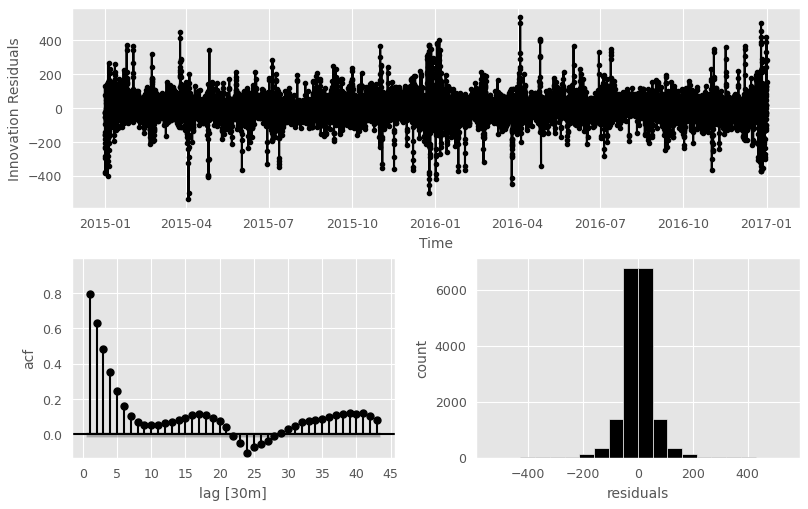

In [ ]:
# # We want to track the best score
# best_aicc = np.inf
# best_k = None

# # Loop through different K values for daily seasonality (m=24)
# # The maximum K is m/2, so for daily data, max K is 12.
# for k_daily in range(1, 11): 
    
#     # 1. Define the features for this iteration
#     features = [
#         partial(fourier, season_length=24, k=k_daily),
#         # partial(fourier, season_length=24 * 7, k=5), 
#         # partial(fourier, season_length=24 * 365, k=3), 
#     ]

#     # 2. Process data through pipeline
#     data_fourier, data_futr_fourier = pipeline(
#         data, features=features, freq="H", h=48
#     )
    
#     # 3. Define and fit the model
#     model = AutoARIMA(max_d=0, seasonal=False, nmodels=20)
#     sf = StatsForecast(models=[model], freq="H")
#     sf = sf.fit(data_fourier, target_col="y")
    
#     # 4. Extract the AICc from the fitted StatsForecast model
#     # The fitted model parameters are stored in a dictionary
#     current_model_stats = sf.fitted_[0, 0].model_
#     current_aicc = current_model_stats['aicc']
    
#     print(f"Testing Daily K={k_daily} | AICc = {current_aicc:.2f}")
    
#     # 5. Check if it's the best one so far
#     if current_aicc < best_aicc:
#         best_aicc = current_aicc
#         best_k = k_daily

# print(f"\nOptimization Complete!")
# print(f"The best model uses K={best_k} for daily seasonality, yielding an AICc of {best_aicc:.2f}")

# Testing Daily K=1 | AICc = 223983.61
# Testing Daily K=2 | AICc = 223950.08
# Testing Daily K=3 | AICc = 223935.71
# Testing Daily K=4 | AICc = 223842.42
# Testing Daily K=5 | AICc = 223609.92
# Testing Daily K=6 | AICc = 223602.94
# Testing Daily K=7 | AICc = 223596.58
# Testing Daily K=8 | AICc = 223588.86
# Testing Daily K=9 | AICc = 223591.99
# Testing Daily K=10 | AICc = 223590.50

# Optimization Complete!
# The best model uses K=8 for daily seasonality, yielding an AICc of 223588.86

In [ ]:
# 1. Define the features for this iteration
features = [
    partial(fourier, season_length=24, k=8),
    partial(fourier, season_length=24 * 7, k=5), 
    partial(fourier, season_length=24 * 365, k=3), 
]

# 2. Process data through pipeline
data_fourier, data_futr_fourier = pipeline(
    data, features=features, freq="H", h=48
)

# 3. Define and fit the model
model = AutoARIMA(max_d=0, seasonal=False, nmodels=20)
sf = StatsForecast(models=[model], freq="H")
sf = sf.fit(data_fourier, target_col="y")

# 4. Extract the AICc from the fitted StatsForecast model
# The fitted model parameters are stored in a dictionary
current_model_stats = sf.fitted_[0, 0].model_

residuals = sf.fitted_[0, 0].model_["residuals"]
fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(data_fourier["ds"], residuals, marker=".")
axes["resid"].set(xlabel="Time", ylabel="Innovation Residuals")
plot_acf(residuals, axes["acf"], zero=False, auto_ylims=True,
    bartlett_confint=False)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [30m]", ylabel="acf", title="")
axes["hist"].hist(residuals, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

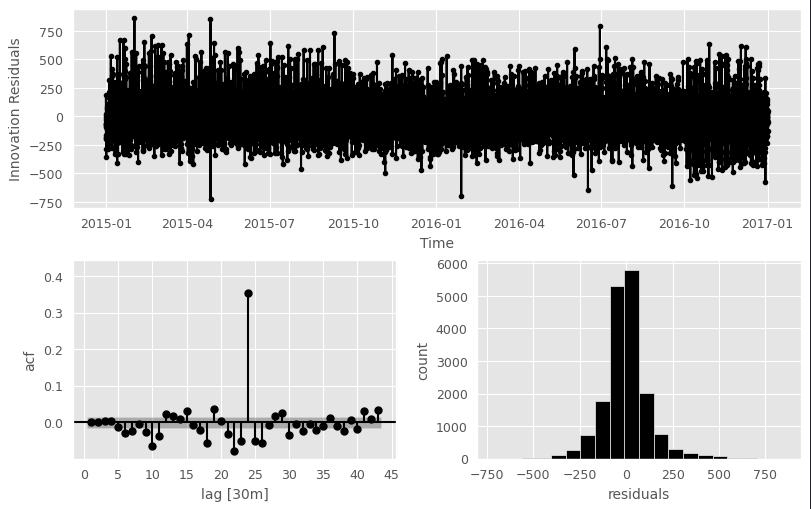

### 2. Consider the weekly data on US finished motor gasoline products supplied (millions of barrels per day) (series `us_gasoline`).

a. Use the Prophet model to forecast the next 13 weeks of data.

b. Repeat the previous exercise using the `AutoARIMA`() and the `AutoETS`() classes from StatsForecast.

c. Compare the accuracy of the models you generated.

In [ ]:
motor = (
    pd.read_csv(DATA_DIR / "us_gasoline.csv", parse_dates=["ds"])
)

length = len(motor)
train = motor.loc[:length - 104,:]
test = motor.loc[length - 104 + 1:,:].reset_index(drop=True)

fig = plot_series(motor, title="Weekly Motor US Gasoline Prices")
display(fig)

In [ ]:
# from sklearn.metrics import mean_squared_error

# best_k = None
# best_rmse = float('inf')

# for k in range(1, 11): # Ví dụ test k từ 1 đến 5
#     m = Prophet(weekly_seasonality=True)
#     m.add_seasonality(name="quarterly", period=4, fourier_order=k)
#     m.fit(train)
    
#     # 1. Dự đoán lại trên tập train
#     forecast = m.predict(train)
    
#     # 2. Tính toán sai số RMSE
#     current_rmse = np.sqrt(mean_squared_error(train['y'], forecast['yhat']))
    
#     print(f"Testing Quarterly K={k} | Train RMSE = {current_rmse:.2f}")
    
#     if current_rmse < best_rmse:
#         best_rmse = current_rmse
#         best_k = k

# print(f"-> K tốt nhất là: {best_k}")
# -> K tốt nhất là: 2

In [ ]:
m = Prophet(weekly_seasonality=True)
# m.add_seasonality(name="quarterly", period=4, fourier_order=2)
m.fit(train)

future = m.make_future_dataframe(periods=len(test), freq="W-MON")
fc_prophet = (
    m.predict(future)[["ds", "yhat", "yhat_lower", "yhat_upper"]]
    .rename(columns={
        "yhat": "Prophet",
        "yhat_lower": "Prophet-lo-80",
        "yhat_upper": "Prophet-hi-80",
    })
)

models = [AutoARIMA(season_length=52), AutoETS(season_length=52)]
sf = StatsForecast(models=models, freq="W-MON")
level = [80]
fc_stats = sf.forecast(df=train, h=len(test), level=level)
fc = fc_stats.merge(fc_prophet, on="ds")

In [ ]:
plot_series(motor, fc, level=level,
    xlabel="Quarter", ylabel="motor prices",
    title="Motor gasoline",
    palette="black_and_3color", rm_legend=False,
)

In [ ]:
evaluation = (
    evaluate(
        fc.merge(test, on=["unique_id", "ds"]),
        metrics=[rmse, mae, mape, partial(mase, seasonality=52)],
        train_df=train,
    )
    .drop(columns="unique_id")
    .sort_values("metric")
    .assign(metric=lambda x: x["metric"].str.upper())
    .set_index("metric").rename_axis("")
    .transpose()
    .rename_axis("Method").reset_index()
    .assign(MAPE=lambda x: 100 * x["MAPE"]) 
)
evaluation